Interactive Data Semi-automatic Anomaly creation pipeline

In [1]:
import os
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch

plt.style.use("seaborn-v0_8")


In [2]:
DATA_DIR = "/Users/darenpalmer/Desktop/UCL/CS/fyp.nosync/data/carOBD/obdiidata"
file_path = os.path.join(DATA_DIR, "drive4.csv")

df = pd.read_csv(file_path)
df.columns = [c.strip() for c in df.columns]
df.head()


,ENGINE_RUN_TINE (),ENGINE_RPM (),VEHICLE_SPEED (),THROTTLE (),ENGINE_LOAD (),COOLANT_TEMPERATURE (),LONG_TERM_FUEL_TRIM_BANK_1 (),SHORT_TERM_FUEL_TRIM_BANK_1 (),INTAKE_MANIFOLD_PRESSURE (),FUEL_TANK (),...,INTAKE_AIR_TEMP (),TIMING_ADVANCE (),CATALYST_TEMPERATURE_BANK1_SENSOR1 (),CATALYST_TEMPERATURE_BANK1_SENSOR2 (),CONTROL_MODULE_VOLTAGE (),COMMANDED_EVAPORATIVE_PURGE (),TIME_RUN_WITH_MIL_ON (),TIME_SINCE_TROUBLE_CODES_CLEARED (),DISTANCE_TRAVELED_WITH_MIL_ON (),WARM_UPS_SINCE_CODES_CLEARED ()
0.0,0.0,0.0,17.647058,0.0,41.0,-4.6875,0.0,101.0,27.843138,49.803921,...,5.0,551.200012,429.899994,12.48,0.0,0.0,10068.0,0.0,255.0,NaN
0.0,0.0,0.0,17.647058,0.0,41.0,-4.6875,0.0,101.0,27.843138,49.803921,...,5.0,551.200012,429.899994,12.48,0.0,0.0,10068.0,0.0,255.0,NaN
0.0,0.0,0.0,17.647058,0.0,41.0,-4.6875,0.0,101.0,27.843138,49.803921,...,5.0,551.200012,429.899994,12.48,0.0,0.0,10068.0,0.0,255.0,NaN
0.0,0.0,0.0,18.823530,0.0,41.0,-4.6875,0.0,100.0,27.843138,49.803921,...,5.0,551.200012,429.899994,12.48,0.0,0.0,10068.0,0.0,255.0,NaN
0.0,0.0,0.0,18.823530,0.0,41.0,-4.6875,0.0,100.0,27.843138,49.803921,...,5.0,551.200012,429.899994,12.48,0.0,0.0,10068.0,0.0,255.0,NaN


In [3]:
def load_all_drives(pattern="drive*.csv"):
    dfs = []
    for path in glob.glob(os.path.join(DATA_DIR, pattern)):
        temp = pd.read_csv(path)
        temp.columns = [c.strip() for c in temp.columns]
        temp["source_file"] = os.path.basename(path)
        dfs.append(temp)
    return dfs  # list of DataFrames

drive_dfs = load_all_drives()


In [4]:
WINDOW_SIZE = 60  # timesteps (assume 1 Hz)
STRIDE = 10

def iter_windows(df, window_size=WINDOW_SIZE, stride=STRIDE):
    n = len(df)
    for start in range(0, n - window_size, stride):
        end = start + window_size
        yield start, end, df.iloc[start:end]


Simple rules based anomaly definition

In [5]:
def rule_fuel_trim_steady(window):
    rpm = window["ENGINE_RPM ()"]
    load = window["ENGINE_LOAD ()"]
    ltft = window["LONG_TERM_FUEL_TRIM_BANK_1 ()"]
    stft = window["SHORT_TERM_FUEL_TRIM_BANK_1 ()"]

    steady = rpm.std() < 200 and load.std() < 5
    long_enough = len(window) >= 60
    trim_bad = (ltft.abs().mean() > 10) or (stft.abs().mean() > 15)

    if steady and long_enough and trim_bad:
        return True, [
            "LONG_TERM_FUEL_TRIM_BANK_1 ()",
            "SHORT_TERM_FUEL_TRIM_BANK_1 ()"
        ], "Fuel trim out of band at steady cruise"
    return False, [], ""


In [6]:
def rule_coolant_warmup(window):
    run_time = window["ENGINE_RUN_TINE ()"]  # note spelling in CSV [file:2]
    coolant = window["COOLANT_TEMPERATURE ()"]

    if run_time.iloc[-1] > 300 and coolant.iloc[-1] < 70:
        return True, ["COOLANT_TEMPERATURE ()"], "Coolant failed to reach warm temp"
    return False, [], ""


Exception for startup window

In [7]:
def is_startup_window(window):
    """Detect if window contains engine startup transient."""
    rpm = window["ENGINE_RPM ()"]
    run_time = window["ENGINE_RUN_TINE ()"]
    
    # Starts from 0 RPM or run_time < 60 seconds
    if rpm.iloc[0] < 100 or run_time.iloc[-1] < 60:
        return True
    return False

Helper to categorize windows

In [8]:
RULES = [rule_fuel_trim_steady, rule_coolant_warmup]

def apply_rules(window):
    fired_rules = []
    sensors = set()
    for rule in RULES:
        fired, sens, reason = rule(window)
        if fired:
            fired_rules.append(reason)
            sensors.update(sens)
    return fired_rules, list(sensors)


In [9]:
normal_windows = []

for start, end, wdf in iter_windows(df):
    # For now, do NOT filter by rules
    normal_windows.append(wdf.values)

print("Normal windows count:", len(normal_windows)) 

normal_array = np.stack(normal_windows)
print("normal_array shape:", normal_array.shape)


Normal windows count: 433
normal_array shape: (433, 60, 27)


Then we prepared datasets for the Github GDN implementation (https://github.com/d-ailin/GDN) and trained the model to produce anomaly scores on each timestamp

Now we load the candidate windows for anomaly annotation 

In [10]:
import pandas as pd
import numpy as np

scores = np.load("/Users/darenpalmer/Desktop/UCL/CS/fyp.nosync/anomaly-detection/data_creation/GDN/results/carobd_scores.npy") # (T_test,)
full_scores = np.load("/Users/darenpalmer/Desktop/UCL/CS/fyp.nosync/anomaly-detection/data_creation/GDN/results/carobd_full_scores.npy") # (num_features, T_test)
normal_scores = np.load("/Users/darenpalmer/Desktop/UCL/CS/fyp.nosync/anomaly-detection/data_creation/GDN/results/carobd_normal_scores.npy")

test_df = pd.read_csv("/Users/darenpalmer/Desktop/UCL/CS/fyp.nosync/anomaly-detection/data_creation/GDN/data/carobd/test.csv")
test_df.columns = [c.strip() for c in test_df.columns]

# realigning the windows post-GDN truncation
aligned_len = min(len(test_df), scores.shape[0])

test_df = test_df.iloc[:aligned_len].reset_index(drop=True)
scores = scores[:aligned_len]

full_scores = full_scores[:, :aligned_len]

len(test_df), scores.shape


(304294, (304294,))

In [11]:
WINDOW_SIZE = 60
STRIDE = 10

def iter_windows(df, window_size=WINDOW_SIZE, stride=STRIDE):
    n = len(df)
    for start in range(0, n - window_size, stride):
        end = start + window_size
        yield start, end, df.iloc[start:end]


Retrieve mean anomaly score per window

In [12]:
window_meta = []

for start, end, wdf in iter_windows(test_df):
    window_score = scores[start:end].mean()
    window_meta.append({
        "start": start,
        "end": end,
        "gdn_score": float(window_score)
    })

window_scores = np.array([m["gdn_score"] for m in window_meta])
p95 = np.percentile(window_scores, 95)   # threshold

Apply the defined rules on the candidates

In [13]:
# Much more aggressive filtering
candidates = []

# Calculate stricter thresholds
p98 = np.percentile(window_scores, 98)      # top 2% instead of top 5%
p99_5 = np.percentile(window_scores, 99.5)  # top 0.5% for "very high"

print(f"GDN Score Distribution:")
print(f"  p50  (median):  {np.percentile(window_scores, 50):.4f}")
print(f"  p95:           {np.percentile(window_scores, 95):.4f}")
print(f"  p98:           {p98:.4f}")
print(f"  p99.5:         {p99_5:.4f}")
print(f"  max:           {np.max(window_scores):.4f}")

for meta in window_meta:
    start, end = meta["start"], meta["end"]
    wdf = test_df.iloc[start:end]
    
    # Skip startup windows
    if is_startup_window(wdf):
        continue
    
    fired_rules, sensors = apply_rules(wdf)
    rule_hit = (len(fired_rules) > 0)
    
    # STRICTER: Require BOTH rule AND high GDN (p98), OR extremely high GDN (p99.5)
    high_gdn = meta["gdn_score"] > p98
    very_high_gdn = meta["gdn_score"] > p99_5
    
    # Include if: (rule fired AND score is top 2%) OR (score is top 0.5%)
    if (rule_hit and high_gdn) or very_high_gdn:
        candidates.append({
            "start": start,
            "end": end,
            "gdn_score": meta["gdn_score"],
            "rules": "; ".join(fired_rules),
            "suggested_sensors": "; ".join(sensors)
        })

cand_df = pd.DataFrame(candidates)
cand_df.to_csv("carobd_candidates.csv", index=False)
print(f"\n✓ Filtered candidates: {len(candidates)} (down from 58,655)")
len(candidates)

GDN Score Distribution:
  p50  (median):  1.3895
  p95:           7.9249
  p98:           28.5066
  p99.5:         30.6882
  max:           31.1468

✓ Filtered candidates: 152 (down from 58,655)


152

## 2. Sample strategically

Take top anomalies + random sample for balanced labeling

In [14]:
# Sample intelligently from filtered candidates
# If we have <500 candidates, use all of them
# Otherwise, take top 50 by GDN + 50 random from rest

if len(cand_df) <= 500:
    # Use all filtered candidates
    final_candidates = cand_df.reset_index(drop=True)
    print(f"Using all {len(final_candidates)} filtered candidates")
else:
    # Stratified sample
    cand_df_sorted = cand_df.sort_values("gdn_score", ascending=False).reset_index(drop=True)
    
    top_50 = cand_df_sorted.head(50)
    random_50 = cand_df_sorted.iloc[50:].sample(50, random_state=42)
    
    final_candidates = pd.concat([top_50, random_50]).reset_index(drop=True)
    print(f"Sampled 100 candidates: top 50 + 50 random")

# Overwrite for annotation interface
cand_df = final_candidates
cand_df.to_csv("carobd_candidates_filtered.csv", index=False)
print(f"\n✓ Final candidates to review: {len(cand_df)}")
len(cand_df)

Using all 152 filtered candidates

✓ Final candidates to review: 152


152

## 3. Sample normal windows for balanced dataset

Generate ~100 clearly normal examples (low GDN, no rules)

In [15]:
# Sample 100 clearly normal windows (low GDN, no rules)
normal_candidates = []

p50 = np.percentile(window_scores, 50)

for meta in window_meta:
    if meta["gdn_score"] < p50:  # bottom 50%
        start, end = meta["start"], meta["end"]
        wdf = test_df.iloc[start:end]
        
        # Skip startup windows
        if is_startup_window(wdf):
            continue
        
        fired_rules, _ = apply_rules(wdf)
        if len(fired_rules) == 0:  # no rules fired
            normal_candidates.append({
                "start": start,
                "end": end,
                "gdn_score": meta["gdn_score"],
                "rules": "",
                "suggested_sensors": "",
                "label": 0  # pre-label as normal
            })

# Sample 100 normal windows (or all if <100 available)
n_normal = min(100, len(normal_candidates))
normal_sample = pd.DataFrame(normal_candidates).sample(n=n_normal, random_state=42)

normal_sample.to_csv("carobd_normals.csv", index=False)
print(f"✓ Sampled {len(normal_sample)} normal windows (low GDN, no rules)")
print(f"\nYou now have:")
print(f"  - {len(cand_df)} suspicious windows to label manually")
print(f"  - {len(normal_sample)} normal windows (pre-labeled)")
print(f"\nTotal dataset: {len(cand_df) + len(normal_sample)} windows")
len(normal_sample)

✓ Sampled 0 normal windows (low GDN, no rules)

You now have:
  - 152 suspicious windows to label manually
  - 0 normal windows (pre-labeled)

Total dataset: 152 windows


0

Plot

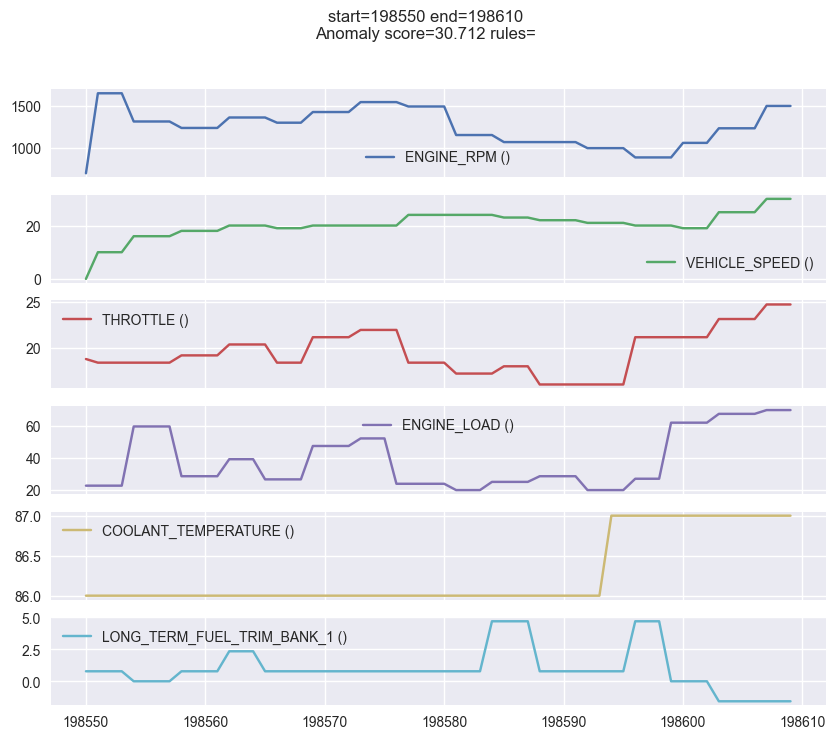

In [16]:
KEY_PIDS = [
    "ENGINE_RPM ()", "VEHICLE_SPEED ()", "THROTTLE ()",
    "ENGINE_LOAD ()", "COOLANT_TEMPERATURE ()",
    "LONG_TERM_FUEL_TRIM_BANK_1 ()"
]

def plot_candidate(idx):
    meta = cand_df.iloc[idx]
    
    if "note" in meta and pd.isna(meta.get("start")):
        print(f"Skipping window {idx}: {meta['note']}")
        return
    
    start = int(meta["start"])
    end = int(meta["end"])
    
    wdf = test_df.iloc[start:end]
    ax = wdf[KEY_PIDS].plot(subplots=True, figsize=(10, 8), sharex=True)
    plt.suptitle(
        f"start={start} end={end}\n"
        f"Anomaly score={meta['gdn_score']:.3f} rules={meta['rules']}"
    )
    plt.show()

plot_candidate(0)


## Annotation Interface Setup

Interactive labeling interface for OBD-II time series anomaly classification.

**Keyboard Shortcuts:**
- `0` or `n` = Label as Normal
- `1` or `a` = Label as Anomalous
- `u` = Mark as Uncertain
- `b` = Go Back to previous window
- `s` = Save progress
- `q` = Quit and save

**Instructions:**
Use the OBD diagnostic criteria table below to evaluate each window. Look for sustained deviations from normal ranges, not transient spikes.

In [17]:
import ipywidgets as widgets
from IPython.display import display, clear_output, HTML
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from pathlib import Path
import json

# Configuration
KEY_PIDS = [
    "ENGINE_RPM ()",
    "VEHICLE_SPEED ()",
    "THROTTLE ()",
    "ENGINE_LOAD ()",
    "COOLANT_TEMPERATURE ()",
    "LONG_TERM_FUEL_TRIM_BANK_1 ()"
]

WINDOW_SIZE = 60
STRIDE = 10

# Create annotation state
class AnnotationState:
    def __init__(self, cand_df, test_df, scores, save_path="carobd_annotation_progress.csv"):
        self.cand_df = cand_df.copy()
        self.test_df = test_df
        self.scores = scores
        self.save_path = save_path
        self.current_idx = 0
        self.labels = {}
        self.history = []  # for undo
        self.save_interval = 10  # auto-save every N annotations
        self.annotation_count = 0
        
        # Initialize label column if not exists
        if "label" not in self.cand_df.columns:
            self.cand_df["label"] = np.nan
        
        self.load_progress()
    
    def load_progress(self):
        """Load existing annotations from CSV if available."""
        if Path(self.save_path).exists():
            saved_df = pd.read_csv(self.save_path)
            if "label" in saved_df.columns:
                for idx, row in saved_df.iterrows():
                    if not pd.isna(row.get("label")):
                        self.labels[int(row.get("window_idx", idx))] = int(row["label"])
                        self.cand_df.loc[idx, "label"] = int(row["label"])
                print(f"✓ Loaded {len(self.labels)} previous annotations")
    
    def set_label(self, label_value):
        """Record a label for current window."""
        self.labels[self.current_idx] = label_value
        self.cand_df.loc[self.current_idx, "label"] = label_value
        self.history.append((self.current_idx, label_value))
        self.annotation_count += 1
        
        if self.annotation_count % self.save_interval == 0:
            self.save_progress()
    
    def next_window(self):
        """Advance to next window."""
        if self.current_idx < len(self.cand_df) - 1:
            self.current_idx += 1
            return True
        return False
    
    def prev_window(self):
        """Go back to previous window."""
        if self.current_idx > 0:
            self.current_idx -= 1
            return True
        return False
    
    def get_progress(self):
        """Get labeling progress."""
        labeled = len([v for v in self.labels.values() if not pd.isna(v)])
        total = len(self.cand_df)
        return labeled, total
    
    def save_progress(self):
        """Save annotations to CSV."""
        save_df = self.cand_df[["start", "end", "gdn_score", "rules", "suggested_sensors", "label"]].copy()
        save_df.index.name = "window_idx"
        save_df.to_csv(self.save_path)
        labeled, total = self.get_progress()
        print(f"✓ Saved progress: {labeled}/{total} labeled ({100*labeled/total:.1f}%)")

# Initialize state (assumes cand_df, test_df, scores are in scope from above)
try:
    state = AnnotationState(cand_df, test_df, scores)
    print(f"✓ Annotation interface initialized")
    labeled, total = state.get_progress()
    print(f"  Current progress: {labeled}/{total} labeled")
except NameError as e:
    print(f"⚠ Required data not loaded yet: {e}")


✓ Loaded 0 previous annotations
✓ Annotation interface initialized
  Current progress: 0/152 labeled


In [18]:
# OBD Diagnostic Criteria Reference Table
criteria_html = """
<table style="border-collapse: collapse; width: 100%; font-size: 13px;">
  <thead>
    <tr style="background-color: #4CAF50; color: white;">
      <th style="border: 1px solid #ddd; padding: 8px; text-align: left;">Signal</th>
      <th style="border: 1px solid #ddd; padding: 8px; text-align: left;">Normal Range</th>
      <th style="border: 1px solid #ddd; padding: 8px; text-align: left;">Anomalous</th>
      <th style="border: 1px solid #ddd; padding: 8px; text-align: left;">Interpretation</th>
    </tr>
  </thead>
  <tbody>
    <tr style="background-color: #f2f2f2;">
      <td style="border: 1px solid #ddd; padding: 8px;"><strong>LTFT (Long-term Fuel Trim)</strong></td>
      <td style="border: 1px solid #ddd; padding: 8px;">±8%</td>
      <td style="border: 1px solid #ddd; padding: 8px;"><span style="color: red;"><strong>&gt;±10% sustained</strong></span></td>
      <td style="border: 1px solid #ddd; padding: 8px;">Vacuum leak, fuel system pressure issue, sensor drift</td>
    </tr>
    <tr>
      <td style="border: 1px solid #ddd; padding: 8px;"><strong>STFT (Short-term Fuel Trim)</strong></td>
      <td style="border: 1px solid #ddd; padding: 8px;">±10%</td>
      <td style="border: 1px solid #ddd; padding: 8px;"><span style="color: red;"><strong>&gt;±15% sustained</strong></span></td>
      <td style="border: 1px solid #ddd; padding: 8px;">O2 sensor fault, fuel injector failure, air intake leak</td>
    </tr>
    <tr style="background-color: #f2f2f2;">
      <td style="border: 1px solid #ddd; padding: 8px;"><strong>Coolant Temp (°C)</strong></td>
      <td style="border: 1px solid #ddd; padding: 8px;">85–95°C (warm in 5–8 min)</td>
      <td style="border: 1px solid #ddd; padding: 8px;"><span style="color: red;"><strong>&lt;70°C after 5 min run</strong></span></td>
      <td style="border: 1px solid #ddd; padding: 8px;">Stuck thermostat (open), coolant level issue, temp sensor fault</td>
    </tr>
    <tr>
      <td style="border: 1px solid #ddd; padding: 8px;"><strong>RPM–Speed Coupling</strong></td>
      <td style="border: 1px solid #ddd; padding: 8px;">Proportional (gear ratio)</td>
      <td style="border: 1px solid #ddd; padding: 8px;"><span style="color: red;"><strong>Decoupled &gt;10s</strong></span></td>
      <td style="border: 1px solid #ddd; padding: 8px;">Transmission slip, wheel spin, sensor malfunction</td>
    </tr>
    <tr style="background-color: #f2f2f2;">
      <td style="border: 1px solid #ddd; padding: 8px;"><strong>Throttle–Load Correlation</strong></td>
      <td style="border: 1px solid #ddd; padding: 8px;">Correlated (↑throttle → ↑load)</td>
      <td style="border: 1px solid #ddd; padding: 8px;"><span style="color: red;"><strong>High load + low throttle</strong></span></td>
      <td style="border: 1px solid #ddd; padding: 8px;">Throttle position sensor drift, MAP sensor fault</td>
    </tr>
    <tr>
      <td style="border: 1px solid #ddd; padding: 8px;"><strong>Engine Load (%)</strong></td>
      <td style="border: 1px solid #ddd; padding: 8px;">0–100% (varies with speed/throttle)</td>
      <td style="border: 1px solid #ddd; padding: 8px;"><span style="color: red;"><strong>Stuck at extremes (0% or 100%)</strong></span></td>
      <td style="border: 1px solid #ddd; padding: 8px;">MAP sensor stuck, ECU fault, load calculation error</td>
    </tr>
  </tbody>
</table>
<br>
<p style="font-size: 12px; color: #666;">
<strong>Key Principle:</strong> Look for <em>sustained</em> deviations from normal operating ranges, not transient spikes. 
Startup transients (first 60 seconds) and coastdown periods should be treated cautiously.
</p>
"""

display(HTML(criteria_html))


Signal,Normal Range,Anomalous,Interpretation
LTFT (Long-term Fuel Trim),±8%,>±10% sustained,"Vacuum leak, fuel system pressure issue, sensor drift"
STFT (Short-term Fuel Trim),±10%,>±15% sustained,"O2 sensor fault, fuel injector failure, air intake leak"
Coolant Temp (°C),85–95°C (warm in 5–8 min),<70°C after 5 min run,"Stuck thermostat (open), coolant level issue, temp sensor fault"
RPM–Speed Coupling,Proportional (gear ratio),Decoupled >10s,"Transmission slip, wheel spin, sensor malfunction"
Throttle–Load Correlation,Correlated (↑throttle → ↑load),High load + low throttle,"Throttle position sensor drift, MAP sensor fault"
Engine Load (%),0–100% (varies with speed/throttle),Stuck at extremes (0% or 100%),"MAP sensor stuck, ECU fault, load calculation error"


In [ ]:
# Core Annotation Interface
class AnnotationInterface:
    def __init__(self, state):
        self.state = state
        self.plot_output = widgets.Output()
        self.info_output = widgets.Output()
        self.message_output = widgets.Output()
        
        # Buttons
        self.btn_normal = widgets.Button(description="Normal (0)", button_style="info", tooltip="Label as Normal", layout=widgets.Layout(width="120px"))
        self.btn_anomaly = widgets.Button(description="Anomaly (1)", button_style="danger", tooltip="Label as Anomalous", layout=widgets.Layout(width="120px"))
        self.btn_uncertain = widgets.Button(description="Uncertain (u)", button_style="warning", tooltip="Skip for now", layout=widgets.Layout(width="120px"))
        self.btn_prev = widgets.Button(description="← Back", button_style="success", tooltip="Previous window", layout=widgets.Layout(width="100px"))
        self.btn_save = widgets.Button(description="Save (s)", button_style="success", tooltip="Save to CSV", layout=widgets.Layout(width="100px"))
        self.btn_quit = widgets.Button(description="Quit (q)", button_style="danger", tooltip="Save and exit", layout=widgets.Layout(width="100px"))
        
        # Keyboard event handler
        self.register_keyboard_handler()
        
        # Callbacks
        self.btn_normal.on_click(self.on_normal_clicked)
        self.btn_anomaly.on_click(self.on_anomaly_clicked)
        self.btn_uncertain.on_click(self.on_uncertain_clicked)
        self.btn_prev.on_click(self.on_prev_clicked)
        self.btn_save.on_click(self.on_save_clicked)
        self.btn_quit.on_click(self.on_quit_clicked)
    
    def register_keyboard_handler(self):
        """Register global keyboard event handler for Jupyter."""
        try:
            from IPython.core.events import EventManager
            from IPython.core.display import DisplayObject
            
            # This requires manual event binding at display time
            # We'll use a JavaScript approach instead
            js_code = """
            <script>
            document.addEventListener('keydown', function(event) {
                const key = event.key.toLowerCase();
                if (['0', 'n'].includes(key)) {
                    document.querySelector('button[title="Label as Normal"]')?.click();
                } else if (['1', 'a'].includes(key)) {
                    document.querySelector('button[title="Label as Anomalous"]')?.click();
                } else if (key === 'u') {
                    document.querySelector('button[title="Skip for now"]')?.click();
                } else if (key === 'b') {
                    document.querySelector('button[title="Previous window"]')?.click();
                } else if (key === 's') {
                    document.querySelector('button[title="Save to CSV"]')?.click();
                } else if (key === 'q') {
                    document.querySelector('button[title="Save and exit"]')?.click();
                }
            }, false);
            </script>
            """
            display(HTML(js_code))
        except:
            pass  # Fall back to button clicks only
    
    def on_normal_clicked(self, b):
        self.state.set_label(0)
        self.show_message("✓ Labeled as NORMAL")
        if self.state.next_window():
            self.update_display()
        else:
            self.show_message("✓ Labeled as NORMAL | ✓ All windows annotated! Press 'Save' to finalize.")
    
    def on_anomaly_clicked(self, b):
        self.state.set_label(1)
        self.show_message("✓ Labeled as ANOMALOUS")
        if self.state.next_window():
            self.update_display()
        else:
            self.show_message("✓ Labeled as ANOMALOUS | ✓ All windows annotated! Press 'Save' to finalize.")
    
    def on_uncertain_clicked(self, b):
        self.show_message("⊗ Skipped (marked as uncertain)")
        if self.state.next_window():
            self.update_display()
        else:
            self.show_message("⊗ Skipped | ✓ All windows processed!")
    
    def on_prev_clicked(self, b):
        if self.state.prev_window():
            self.show_message("← Returned to previous window")
            self.update_display()
        else:
            self.show_message("Already at first window")
    
    def on_save_clicked(self, b):
        self.state.save_progress()
        labeled, total = self.state.get_progress()
        self.show_message(f"✓ Saved! Progress: {labeled}/{total} ({100*labeled/total:.1f}%)")
    
    def on_quit_clicked(self, b):
        self.state.save_progress()
        labeled, total = self.state.get_progress()
        self.show_message(f"✓ SAVED AND QUIT | Final: {labeled}/{total} ({100*labeled/total:.1f}%) labeled")
    
    def show_message(self, msg):
        """Display a status message."""
        self.message_output.clear_output()
        with self.message_output:
            print(f"\n{msg}\n")
    
    def plot_window(self, idx):
        """Plot the current window with anomaly scores overlay."""
        row = self.state.cand_df.iloc[idx]
        start, end = int(row["start"]), int(row["end"])
        wdf = self.state.test_df.iloc[start:end]
        window_scores = self.state.scores[start:end]
        
        fig, axes = plt.subplots(len(KEY_PIDS) + 1, 1, figsize=(13, 10), sharex=True)
        
        # Plot each PID
        for i, pid in enumerate(KEY_PIDS):
            axes[i].plot(wdf[pid].values, linewidth=1.5, color="steelblue")
            axes[i].set_ylabel(pid.replace(" ()", ""), fontsize=10)
            axes[i].grid(True, alpha=0.3)
        
        # Plot anomaly scores
        axes[-1].plot(window_scores, linewidth=1.5, color="red", alpha=0.7, label="GDN Score")
        axes[-1].axhline(np.percentile(window_scores, 95), color="orange", linestyle="--", label="95th percentile")
        axes[-1].set_ylabel("Anomaly Score", fontsize=10)
        axes[-1].set_xlabel("Timestep (1 Hz)", fontsize=10)
        axes[-1].legend(loc="upper right")
        axes[-1].grid(True, alpha=0.3)
        
        plt.tight_layout()
        return fig
    
    def update_display(self):
        """Update the full interface display."""
        idx = self.state.current_idx
        row = self.state.cand_df.iloc[idx]
        labeled, total = self.state.get_progress()
        
        # Clear previous outputs
        self.plot_output.clear_output()
        self.info_output.clear_output()
        
        # Plot
        with self.plot_output:
            fig = self.plot_window(idx)
            plt.show()
            plt.close(fig)
        
        # Info panel
        with self.info_output:
            label_status = "✓ Already labeled" if not pd.isna(row.get("label")) else "⚪ Pending"
            rules_text = row.get("rules", "None") if row.get("rules") else "None"
            sensors_text = row.get("suggested_sensors", "None") if row.get("suggested_sensors") else "None"
            
            info_html = f"""
            <div style="background-color: #f9f9f9; padding: 15px; border-radius: 5px; border-left: 4px solid #4CAF50;">
                <h3 style="margin-top: 0;">Window {idx + 1} / {total}</h3>
                <table style="font-size: 13px; width: 100%;">
                    <tr><td><strong>Status:</strong></td><td>{label_status}</td></tr>
                    <tr><td><strong>Progress:</strong></td><td>{labeled}/{total} labeled ({100*labeled/total:.1f}%)</td></tr>
                    <tr><td><strong>Indices:</strong></td><td>start={int(row['start'])}, end={int(row['end'])}</td></tr>
                    <tr><td><strong>GDN Score:</strong></td><td><span style="color: red; font-weight: bold;">{row['gdn_score']:.4f}</span></td></tr>
                    <tr><td><strong>Rules Fired:</strong></td><td>{rules_text}</td></tr>
                    <tr><td><strong>Suggested Sensors:</strong></td><td>{sensors_text}</td></tr>
                </table>
            </div>
            """
            display(HTML(info_html))
    
    def show(self):
        """Display the full annotation interface."""
        print("=" * 80)
        print("OBD-II TIME SERIES ANOMALY ANNOTATION INTERFACE")
        print("=" * 80)
        print()
        
        # Create layout
        button_row1 = widgets.HBox([self.btn_normal, self.btn_anomaly, self.btn_uncertain])
        button_row2 = widgets.HBox([self.btn_prev, self.btn_save, self.btn_quit])
        button_box = widgets.VBox([button_row1, button_row2])
        
        main_layout = widgets.VBox([
            self.plot_output,
            self.info_output,
            button_box,
            self.message_output
        ])
        
        self.update_display()
        display(main_layout)

# Initialize and show interface
try:
    interface = AnnotationInterface(state)
    interface.show()
except Exception as e:
    print(f"Error initializing interface: {e}")
    import traceback
    traceback.print_exc()


OBD-II TIME SERIES ANOMALY ANNOTATION INTERFACE



In [20]:
def print_annotation_summary():
    """Print summary statistics of annotations."""
    labeled, total = state.get_progress()
    
    normal_count = (state.cand_df["label"] == 0).sum()
    anomaly_count = (state.cand_df["label"] == 1).sum()
    uncertain_count = state.cand_df["label"].isna().sum()
    
    print("\n" + "="*60)
    print("ANNOTATION SUMMARY")
    print("="*60)
    print(f"Total windows: {total}")
    print(f"Labeled: {labeled} ({100*labeled/total:.1f}%)")
    print(f"  ✓ Normal (0): {normal_count} ({100*normal_count/total:.1f}%)")
    print(f"  ✗ Anomalous (1): {anomaly_count} ({100*anomaly_count/total:.1f}%)")
    print(f"  ⊗ Uncertain/Skipped: {uncertain_count} ({100*uncertain_count/total:.1f}%)")
    print("="*60 + "\n")

def export_final_dataset(output_path="carobd_annotated_final.csv"):
    """Export the final annotated dataset."""
    output_df = state.cand_df[state.cand_df["label"].notna()].copy()
    output_df.to_csv(output_path, index=False)
    print(f"✓ Exported {len(output_df)} labeled windows to: {output_path}")
    return output_df

def plot_gdn_score_distribution():
    """Plot distribution of GDN scores by label."""
    labeled_df = state.cand_df[state.cand_df["label"].notna()]
    
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
    
    normal = labeled_df[labeled_df["label"] == 0]["gdn_score"]
    anomaly = labeled_df[labeled_df["label"] == 1]["gdn_score"]
    
    ax1.hist(normal, bins=30, alpha=0.6, label="Normal", color="green")
    ax1.hist(anomaly, bins=30, alpha=0.6, label="Anomalous", color="red")
    ax1.set_xlabel("GDN Score")
    ax1.set_ylabel("Count")
    ax1.set_title("GDN Score Distribution by Label")
    ax1.legend()
    ax1.grid(True, alpha=0.3)
    
    data_to_plot = [normal, anomaly]
    ax2.boxplot(data_to_plot, labels=["Normal", "Anomalous"])
    ax2.set_ylabel("GDN Score")
    ax2.set_title("GDN Score Box Plot")
    ax2.grid(True, alpha=0.3, axis="y")
    
    plt.tight_layout()
    plt.show()

print("\n✓ Analysis functions ready!")
print("Use: print_annotation_summary() | export_final_dataset() | plot_gdn_score_distribution()")



✓ Analysis functions ready!
Use: print_annotation_summary() | export_final_dataset() | plot_gdn_score_distribution()
